In [1]:
# ================================================================
# BELGIAN ELECTRICITY PRICE FORECASTING — LSTM PIPELINE
# ================================================================
# Dataset : Hourly Belgian/French electricity market data (2023–)
# Target  : Price_BE — Belgian day-ahead spot price (€/MWh)
# Horizon : Predict next 72 h using a 168-h (7-day) lookback window
# Model   : Multivariate LSTM with lag features and calendar encoding
# Metrics : MAE and MSE (both in original €/MWh units after inversion)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler          # handles extreme price spikes
from sklearn.linear_model import Lasso                  # LEAR linear baseline
from sklearn.multioutput import MultiOutputRegressor    # one Lasso per forecast hour
from sklearn.metrics import mean_absolute_error, mean_squared_error
import holidays                                         # Belgian public holiday calendar
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Cleaning

The dataset (`Full_Dataset.csv`) contains hourly Belgian and French electricity market variables:
`Price_BE` (target, €/MWh), `Load_FR`, `Gen_FR`, `Price_CH`, `Wind_BE`, `Solar_BE`, `Load_BE`.

Missing values (mainly in `Gen_FR`) are filled by **linear interpolation** followed by **backward-fill** for any remaining edge NaNs.
Data is restricted to **2023 onward** to capture the post-energy-crisis market regime, which differs structurally from earlier years.

In [2]:
# Load Data
df = pd.read_csv('Full_Dataset.csv')

# Parse European dates and set as the timeline index
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y %H:%M')
df.set_index('Date', inplace=True)

# Sort out missing values
print("Missing values before cleaning:")
print(df.isna().sum())
df.interpolate(method='linear', inplace=True)
df.bfill(inplace=True) 
print("\nMissing values after cleaning:")
print(df.isna().sum())

# Keep only data from 2023 onwards
df = df.loc['2023-01-01':] 

print(f"Total hours of data: {len(df)}")
df.head(3)

Missing values before cleaning:
Price_BE      0
Load_FR       3
Gen_FR      292
Price_CH      0
Wind_BE       5
Solar_BE      5
Load_BE       0
dtype: int64

Missing values after cleaning:
Price_BE    0
Load_FR     0
Gen_FR      0
Price_CH    0
Wind_BE     0
Solar_BE    0
Load_BE     0
dtype: int64
Total hours of data: 27630


,Price_BE,Load_FR,Gen_FR,Price_CH,Wind_BE,Solar_BE,Load_BE
Date,,,,,,,
2023-01-01 00:00:00,-1.75,44900.0,42169.75,-7.25,2165.0250,0.0,7593.496667
2023-01-01 01:00:00,-1.46,43750.0,42059.50,-3.99,2165.3225,0.0,7315.745000
2023-01-01 02:00:00,-5.27,40400.0,40808.50,-7.71,2165.7050,0.0,7068.387500


## 2. Exploratory Correlation Analysis

The scatter matrix visualises pairwise relationships between all market features.
Key observations relevant to the report:
- `Price_BE` ↔ `Price_CH`: strong positive correlation (cross-border market coupling)
- `Solar_BE` / `Wind_BE` ↔ `Price_BE`: negative correlation — renewable surplus pushes prices down (merit-order effect)
- `Load_BE` / `Load_FR` ↔ `Price_BE`: positive correlation — high demand drives prices up

array([[<Axes: xlabel='Price_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Load_FR', ylabel='Price_BE'>,
        <Axes: xlabel='Gen_FR', ylabel='Price_BE'>,
        <Axes: xlabel='Price_CH', ylabel='Price_BE'>,
        <Axes: xlabel='Wind_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Solar_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Load_BE', ylabel='Price_BE'>],
       [<Axes: xlabel='Price_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Load_FR', ylabel='Load_FR'>,
        <Axes: xlabel='Gen_FR', ylabel='Load_FR'>,
        <Axes: xlabel='Price_CH', ylabel='Load_FR'>,
        <Axes: xlabel='Wind_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Solar_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Load_BE', ylabel='Load_FR'>],
       [<Axes: xlabel='Price_BE', ylabel='Gen_FR'>,
        <Axes: xlabel='Load_FR', ylabel='Gen_FR'>,
        <Axes: xlabel='Gen_FR', ylabel='Gen_FR'>,
        <Axes: xlabel='Price_CH', ylabel='Gen_FR'>,
        <Axes: xlabel='Wind_BE', ylabel='Gen_FR'>,
   

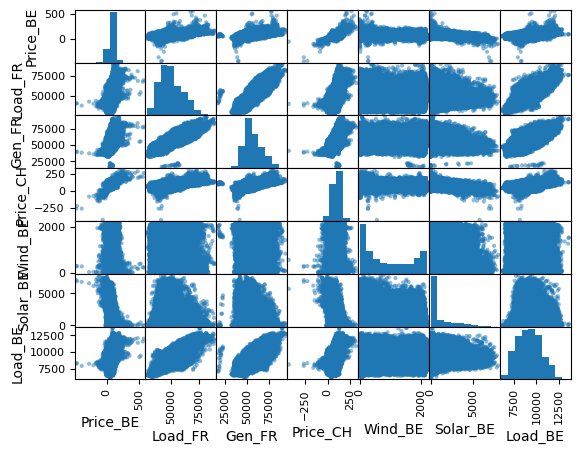

In [3]:
pd.plotting.scatter_matrix(df)


## 3. Feature Engineering

Four categories of features are engineered to improve forecast accuracy:

**Cyclic time encodings** (`sin`/`cos` of hour, day-of-week, month): Capture recurring daily and weekly patterns without a discontinuity at period boundaries (e.g. hour 23 is numerically "close" to hour 0 in sin/cos space, unlike raw integers).

**Binary calendar flags** (`is_weekend`, `is_holiday`): Mark non-working days using the official Belgian public holiday calendar. Demand — and therefore price — drops sharply on these days, a pattern not captured by cyclic encodings alone.

**Raw target** (`Price_BE`): The model predicts actual Belgian day-ahead prices directly in €/MWh. `RobustScaler` is used to handle the raw scale and extreme spikes while preserving the original price distribution.

**Lag features** (`lag_24`, `lag_48`, `lag_72`, `lag_168`): Past values of `Price_BE` at 24 h, 48 h, 72 h, and 168 h (one week) before each step. Electricity prices exhibit very strong daily and weekly seasonality, so these lags are among the most predictive features in energy forecasting literature.

In [4]:
# === Cyclic calendar features ===
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# === Binary calendar features ===
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
be_holidays = holidays.Belgium()
df['is_holiday'] = df.index.normalize().isin(be_holidays).astype(int)

# === Raw target: Price_BE ===
print(f"Raw price min: {df['Price_BE'].min():.2f}  max: {df['Price_BE'].max():.2f}")
df['lag_24']  = df['Price_BE'].shift(24)
df['lag_48']  = df['Price_BE'].shift(48)
df['lag_72']  = df['Price_BE'].shift(72)
df['lag_168'] = df['Price_BE'].shift(168)
df.dropna(inplace=True)

# === Feature groups ===
market_features = ['Price_BE', 'Gen_FR', 'Load_FR', 'Price_CH',
                   'Load_BE', 'Solar_BE', 'Wind_BE',
                   'lag_24', 'lag_48', 'lag_72', 'lag_168']
binary_features = ['is_holiday']
cyclic_features = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
all_features    = market_features + binary_features + cyclic_features

print(f"Hours after dropping lag NaNs: {len(df)}")
print(f"Total features: {len(all_features)}  "
      f"(market+lags: {len(market_features)}, binary: {len(binary_features)}, cyclic: {len(cyclic_features)})")

Raw price min: -462.33  max: 565.46
Hours after dropping lag NaNs: 27462
Total features: 18  (market+lags: 11, binary: 1, cyclic: 6)


## 4. No-Leakage Scaling & Sequence Construction

**Data leakage** occurs when information from the validation set influences preprocessing steps, artificially inflating validation scores. The original pipeline had this problem because `MinMaxScaler` was fitted on the full dataset before splitting.

This is fixed in three explicit steps:
1. **Split first**: The raw DataFrame is divided 80 % train / 20 % validation *before* any scaler is fitted.
2. **Scaler fitted on training data only**: `RobustScaler` computes its median and IQR from training rows exclusively — the validation set's distribution is never seen.
3. **Transform applied to the full dataset**: The train-fitted scaler scales both sets, exactly as it would in production.

**Why `RobustScaler` instead of `MinMaxScaler`?**
`MinMaxScaler` maps to [0, 1] using the global min/max, which are dominated by extreme price spikes (sometimes >500 €/MWh during crises). This severely compresses the normal operating range. `RobustScaler` uses the **median and interquartile range (IQR)**, making it insensitive to outliers and preserving variance in the typical price regime.

**Sliding-window sequences**: Each training sample consists of a 168-step input window (all 19 features) and a 72-step target vector (scaled `Price_BE` only).

In [5]:
LOOK_BACK     = 168   # 7 days of hourly history
PREDICT_AHEAD = 72    # forecast horizon: next 72 hours
SPLIT_RATIO   = 0.8

# --- 1. Split raw DataFrame FIRST (scaler has not seen any data yet) ---
split_index_raw = int(len(df) * SPLIT_RATIO)
df_train_raw    = df.iloc[:split_index_raw]
df_val_raw      = df.iloc[split_index_raw:]
print(f"Train: {len(df_train_raw)} rows  {df_train_raw.index[0].date()} → {df_train_raw.index[-1].date()}")
print(f"Val:   {len(df_val_raw)} rows  {df_val_raw.index[0].date()} → {df_val_raw.index[-1].date()}")

# --- 2. Fit RobustScaler on training data ONLY ---
market_scaler = RobustScaler()
market_scaler.fit(df_train_raw[market_features])

# --- 3. Apply train-fitted scaler to full dataset (binary + cyclic stay as-is) ---
df_scaled = df.copy()
df_scaled[market_features] = market_scaler.transform(df[market_features])
scaled_data = df_scaled[all_features].values

# --- 4. Build sliding-window sequences ---
def create_multivariate_sequences(data, look_back, predict_ahead):
    """X = look_back steps of all features; y = next predict_ahead values of column 0 (Price_BE scaled)."""
    X, y = [], []
    for i in range(len(data) - look_back - predict_ahead + 1):
        X.append(data[i : i + look_back, :])
        y.append(data[i + look_back : i + look_back + predict_ahead, 0])
    return np.array(X), np.array(y)

X, y = create_multivariate_sequences(scaled_data, LOOK_BACK, PREDICT_AHEAD)

# --- 5. Chronological sequence split aligned with the raw split ---
split_index_seq = int(len(X) * SPLIT_RATIO)
X_train, X_val  = X[:split_index_seq], X[split_index_seq:]
y_train, y_val  = y[:split_index_seq], y[split_index_seq:]

print(f"\nX_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    |  y_val:   {y_val.shape}")

Train: 21969 rows  2023-01-08 → 2025-07-12
Val:   5493 rows  2025-07-12 → 2026-02-25

X_train: (21778, 168, 18)  |  y_train: (21778, 72)
X_val:   (5445, 168, 18)    |  y_val:   (5445, 72)


## 5. LSTM Model Architecture & Training

A two-layer unidirectional LSTM is used for direct multi-step forecasting:

| Layer   | Config | Purpose |
|---------|--------|---------|
| LSTM 1  | 128 units, `return_sequences=True` | Learns temporal dependencies across the 168-h lookback |
| Dropout | 20 % | Regularisation — randomly zeroes activations to prevent co-adaptation |
| LSTM 2  | 64 units, `return_sequences=False` | Compresses the full sequence into a single summary vector |
| Dropout | 10 % | Light regularisation on the final representation |
| Dense   | 72 units | Output layer — one neuron per forecast hour (direct multi-output) |

**Why unidirectional only?** Bidirectional LSTMs use both past *and future* context. For classification tasks on complete sequences this is valid, but for **forecasting** future inputs do not yet exist — using them would be information leakage.

**Loss function**: `MAE` — less sensitive to isolated price spikes than `MSE`, which would cause the model to over-focus on rare extreme events at the cost of typical-hour accuracy.

**Early stopping** (`patience=15`): Training halts when validation loss stops improving for 15 consecutive epochs, and the best weights are restored automatically.

In [6]:
# --- Model architecture ---
# Unidirectional LSTM only — Bidirectional is disabled for forecasting (no future context)
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOK_BACK, len(all_features))),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.1),
    Dense(PREDICT_AHEAD)
])
model.compile(optimizer='adam', loss='mae')
model.summary()

# --- Training ---
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
print("Training complete!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 72)             │         4,680 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,352 (505.28 KB)

 Trainable params: 129,352 (505.28 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - loss: 0.4333 - val_loss: 0.3966
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - loss: 0.3212 - val_loss: 0.4232
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - loss: 0.2769 - val_loss: 0.4571
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - loss: 0.2511 - val_loss: 0.4449
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - loss: 0.2344 - val_loss: 0.4750
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - loss: 0.2214 - val_loss: 0.4459
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - loss: 0.2117 - val_loss: 0.4379
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - loss: 0.2035 - val_loss: 0.4541
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.1983 - val_loss: 0.4592
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 39s 115ms/step - loss: 0.1936 - val_loss: 0.4458
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.1903 - val_loss: 0.44

## 6. Training History — Overfitting Check

The loss curve shows training MAE (blue) vs validation MAE (orange) per epoch.

- **Both curves falling together** → the model is learning genuine patterns from the data.
- **Validation MAE rising while training MAE falls** → overfitting: the model memorises the training set and fails to generalise.
- **Early stopping** automatically selects the epoch where validation MAE was lowest and restores those weights.

A well-behaved curve should show rapid early improvement, then both losses plateauing at similar values. A growing gap between the two lines is the overfitting signal.

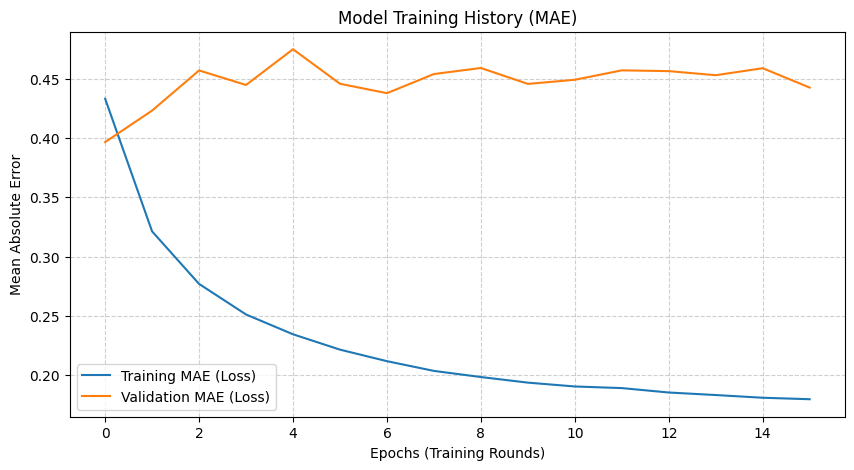

In [7]:
# Plotting the Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training MAE (Loss)')
plt.plot(history.history['val_loss'], label='Validation MAE (Loss)')
plt.title('Model Training History (MAE)')
plt.xlabel('Epochs (Training Rounds)')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6b. Baseline Models

Two baselines establish a performance floor that any useful model must beat:

**Persistence (naïve baseline)**: Predicts the price at hour `t+h` as the observed price at `t+h−72` (same hour, exactly 3 days earlier). Requires no model, no training — it simply copies past values. The LSTM must beat this to justify its complexity.

**LEAR (Lasso-Enhanced AutoRegressive)**: A sparse linear regression model that uses 8 raw price lags (1 h, 24 h, … 168 h before the forecast window) and 6 cyclic calendar features as inputs. One Lasso model is fitted per forecast horizon via `MultiOutputRegressor`. LEAR acts as a strong linear benchmark — outperforming it demonstrates that the LSTM captures non-linear structure beyond what linear models can learn.

In [8]:
# Raw €/MWh prices — df['Price_BE'] is never overwritten.\n
prices_raw = df['Price_BE'].values

# n_total: number of valid sliding windows in the full (post-dropna) dataset
n_total = len(scaled_data) - LOOK_BACK - PREDICT_AHEAD + 1

# Ground-truth price windows (72 h each) aligned with the LSTM sequence windows
y_prices_all = np.array([prices_raw[i + LOOK_BACK : i + LOOK_BACK + PREDICT_AHEAD]
                          for i in range(n_total)])

# Persistence prediction: copy the 72 prices immediately preceding each window
# (same hour, 3 days earlier) — no model, no learning required
y_persist_all = np.array([prices_raw[i + LOOK_BACK - PREDICT_AHEAD : i + LOOK_BACK]
                           for i in range(n_total)])

# Restrict to the validation split (same boundary as the LSTM sequences)
y_prices_val  = y_prices_all[split_index_seq:]
y_persist_val = y_persist_all[split_index_seq:]

persist_mae = mean_absolute_error(y_prices_val, y_persist_val)
persist_mse = mean_squared_error( y_prices_val, y_persist_val)
print(f"Persistence  —  MAE: {persist_mae:.2f} €/MWh  |  MSE: {persist_mse:.2f} €²/MWh²")

# === LEAR: Lasso-Enhanced AutoRegressive model ===
# Feature vector per window: 8 raw price lags + 6 cyclic calendar features
# MultiOutputRegressor fits one independent Lasso per forecast horizon (72 in total)
def build_lear_features(prices, df_index, i, look_back, predict_ahead):
    t        = i + look_back                          # index of the first forecast hour
    lag_vals = [prices[t - lag] for lag in [1, 24, 48, 72, 96, 120, 144, 168]]
    dt       = df_index[t]
    cal = [
        np.sin(2*np.pi*dt.hour/24),      np.cos(2*np.pi*dt.hour/24),
        np.sin(2*np.pi*dt.dayofweek/7),   np.cos(2*np.pi*dt.dayofweek/7),
        np.sin(2*np.pi*(dt.month-1)/12),  np.cos(2*np.pi*(dt.month-1)/12),
    ]
    return lag_vals + cal

X_lear = np.array([build_lear_features(prices_raw, df.index, i, LOOK_BACK, PREDICT_AHEAD)
                   for i in range(n_total)])
y_lear = y_prices_all      # targets in raw €/MWh (no log transform for linear model)

X_lear_train, X_lear_val = X_lear[:split_index_seq], X_lear[split_index_seq:]
y_lear_train, y_lear_val = y_lear[:split_index_seq], y_lear[split_index_seq:]

lear_model = MultiOutputRegressor(Lasso(alpha=0.1, max_iter=5000), n_jobs=-1)
lear_model.fit(X_lear_train, y_lear_train)

y_lear_pred = lear_model.predict(X_lear_val)
lear_mae    = mean_absolute_error(y_lear_val, y_lear_pred)
lear_mse    = mean_squared_error( y_lear_val, y_lear_pred)
print(f"LEAR         —  MAE: {lear_mae:.2f} €/MWh  |  MSE: {lear_mse:.2f} €²/MWh²")

Persistence  —  MAE: 26.41 €/MWh  |  MSE: 1346.20 €²/MWh²
LEAR         —  MAE: 25.33 €/MWh  |  MSE: 1094.03 €²/MWh²


## 7. Evaluation on the Validation Set

All metrics are computed in the **original price unit (€/MWh)** after undoing the scaler transform applied to `Price_BE`.

**MAE (Mean Absolute Error)**: Average absolute deviation between predicted and actual prices. Easy to interpret — an MAE of 10 means predictions are off by 10 €/MWh on average.

**MSE (Mean Squared Error)**: Squares the errors before averaging. Large errors are penalised quadratically, making MSE more sensitive to spike mis-forecasting. High MSE relative to MAE indicates the model struggles specifically on extreme price events.

The sample plot shows a single 72-hour window to qualitatively inspect how well the model tracks price peaks and troughs.

LSTM  —  MAE: 21.47 €/MWh  |  MSE: 830.91 €²/MWh²


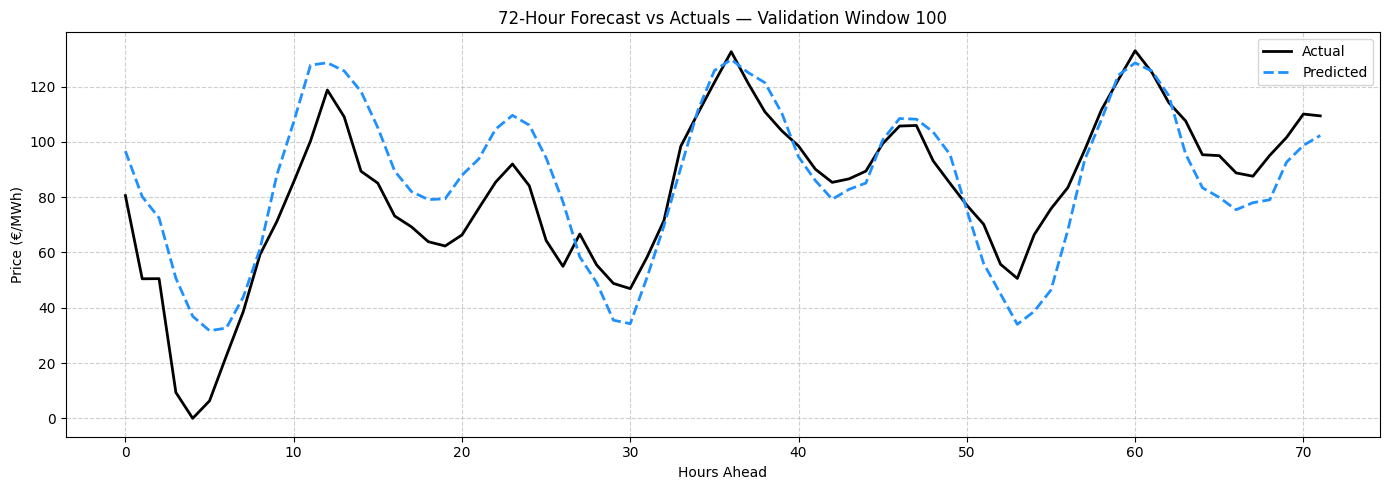

First 5 forecast values: [63.62 53.95 53.68 61.14 68.29] €/MWh


In [9]:
n_market = len(market_features)   # number of columns the RobustScaler was fitted on

def inverse_price(y_scaled, scaler, n_mkt):
    """
    Reverse the RobustScaler transform applied to Price_BE.
    Accepts any NumPy array shape; returns the same shape.
    """
    flat  = y_scaled.flatten()
    dummy = np.zeros((len(flat), n_mkt))
    dummy[:, 0] = flat
    return scaler.inverse_transform(dummy)[:, 0].reshape(y_scaled.shape)

# === Predict across the full validation set ===
y_pred_scaled = model.predict(X_val, verbose=0)
y_pred_euros  = inverse_price(y_pred_scaled, market_scaler, n_market)
y_true_euros  = inverse_price(y_val,          market_scaler, n_market)

# MAE: average absolute deviation — primary metric, directly interpretable in €/MWh
# MSE: squares errors first — amplifies impact of large spike mis-forecasts
lstm_mae = mean_absolute_error(y_true_euros.flatten(), y_pred_euros.flatten())
lstm_mse = mean_squared_error( y_true_euros.flatten(), y_pred_euros.flatten())
print(f"LSTM  —  MAE: {lstm_mae:.2f} €/MWh  |  MSE: {lstm_mse:.2f} €²/MWh²")

# === Sample plot: one 72-hour validation window ===
sample_idx = 100
plt.figure(figsize=(14, 5))
plt.plot(y_true_euros[sample_idx], label='Actual',    color='black',      linewidth=2)
plt.plot(y_pred_euros[sample_idx], label='Predicted', color='dodgerblue', linestyle='--', linewidth=2)
plt.title(f'72-Hour Forecast vs Actuals — Validation Window {sample_idx}')
plt.xlabel('Hours Ahead')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# === Generate predictions.csv — 72-hour forward forecast for submission ===
# Uses the very last 168 hours of the scaled dataset as the input window
last_window  = scaled_data[-LOOK_BACK:].reshape(1, LOOK_BACK, len(all_features))
scaled_pred  = model.predict(last_window, verbose=0)[0]
final_prices = inverse_price(scaled_pred.reshape(1, -1), market_scaler, n_market).flatten()

pd.DataFrame(final_prices).to_csv('predictions.csv', index=False, header=False)
final_prices = inverse_price(scaled_pred.reshape(1, -1), market_scaler, n_market).flatten()
print(f"First 5 forecast values: {final_prices[:5].round(2)} €/MWh")

## 8. Probabilistic Forecast — Monte Carlo Dropout

A standard LSTM produces a single **point prediction** with no uncertainty estimate. **Monte Carlo (MC) Dropout** approximates a Bayesian predictive distribution at near-zero extra cost:

1. Dropout layers are left **active during inference** (`training=True`).
2. The same input window is passed through the model **100 times** — each pass produces a slightly different output because dropout randomly masks different neurons.
3. The 100 outputs form an empirical distribution from which percentiles are extracted.

**Interpreting the bands:**
- **P10–P90 shaded band**: 80 % prediction interval — the model expects the true price to fall within this band 8 times out of 10.
- **P50 (median)**: robust central estimate, less influenced by outlier simulations than the mean.
- **Wide bands** → high model uncertainty, typically at price spikes or at longer horizons where compounding error accumulates.

For a report context: MC Dropout uncertainty is practically relevant for risk management — an energy trader needs not just an expected price but a plausible range to size positions and set stop-losses.

Running 100 Monte Carlo simulations (Dropout ON at inference)...


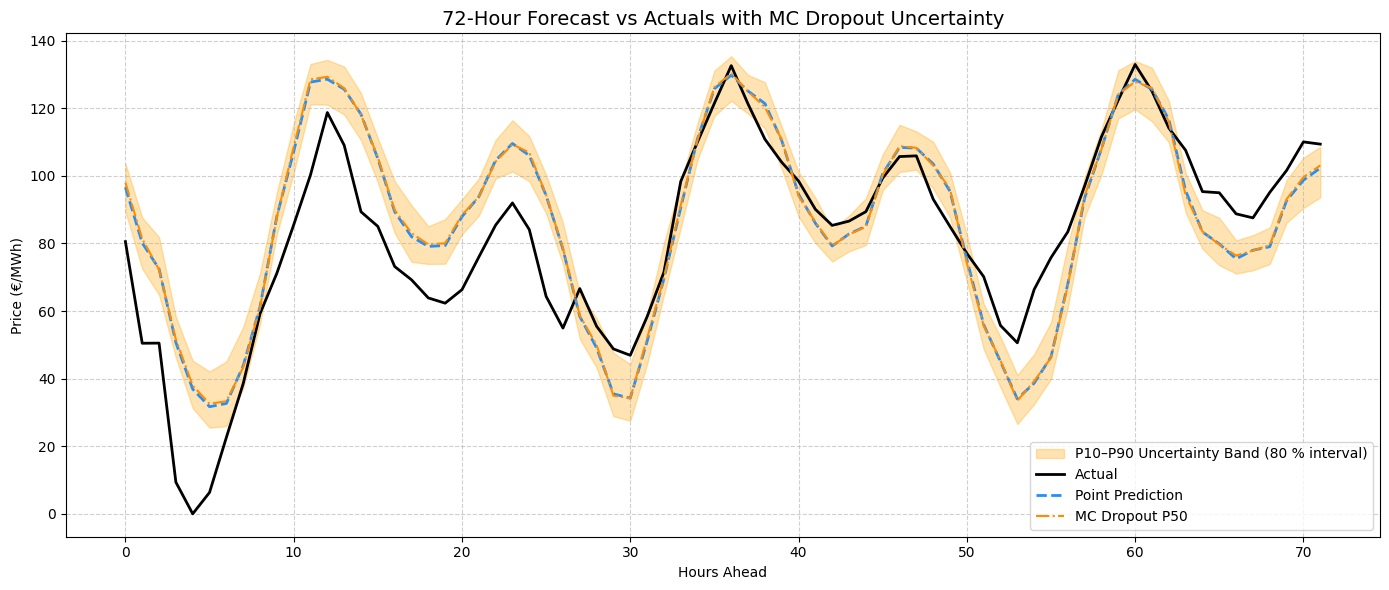

Sample window — MAE: 12.72 €/MWh  |  MSE: 247.63 €²/MWh²


In [12]:
# Monte Carlo Dropout — uncertainty estimation via stochastic inference
# Dropout is reactivated at inference time (training=True): each of the 100 forward
# passes masks different neurons, producing a slightly different output.
# The spread of these 100 outputs approximates the model's predictive uncertainty.

sample_index    = 100
X_sample        = X_val[sample_index : sample_index + 1]

# Point prediction and ground truth in €/MWh
y_actual        = inverse_price(y_val[sample_index].reshape(1, -1),
                                market_scaler, n_market).flatten()
y_pred_standard = inverse_price(model.predict(X_sample, verbose=0),
                                market_scaler, n_market).flatten()

print("Running 100 Monte Carlo simulations (Dropout ON at inference)...")
n_iterations = 100
mc_preds = np.array([
    inverse_price(model(X_sample, training=True).numpy(),
                  market_scaler, n_market).flatten()
    for _ in range(n_iterations)
])

p10 = np.percentile(mc_preds, 10, axis=0)   # lower bound: 10th percentile
p50 = np.percentile(mc_preds, 50, axis=0)   # robust centre: median
p90 = np.percentile(mc_preds, 90, axis=0)   # upper bound: 90th percentile

hours = range(PREDICT_AHEAD)
plt.figure(figsize=(14, 6))
plt.fill_between(hours, p10, p90, color='orange', alpha=0.3, label='P10–P90 Uncertainty Band (80 % interval)')
plt.plot(hours, y_actual,        label='Actual',           color='black',      linewidth=2)
plt.plot(hours, y_pred_standard, label='Point Prediction', color='dodgerblue', linestyle='--', linewidth=2)
plt.plot(hours, p50,             label='MC Dropout P50',   color='darkorange', linestyle='-.')
plt.title('72-Hour Forecast vs Actuals with MC Dropout Uncertainty', fontsize=14)
plt.xlabel('Hours Ahead')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Point-prediction accuracy for this specific sample window
mae_s = mean_absolute_error(y_actual, y_pred_standard)
mse_s = mean_squared_error( y_actual, y_pred_standard)
print(f"Sample window — MAE: {mae_s:.2f} €/MWh  |  MSE: {mse_s:.2f} €²/MWh²")

## 9. Model Comparison Summary

All three models are evaluated on the **same held-out validation set** (chronological 20 % split, no leakage).

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean(&#124;actual − predicted&#124;) | Average error in €/MWh — intuitive, robust to outliers |
| **MSE** | mean((actual − predicted)²) | Penalises large errors quadratically — sensitive to spike mis-forecasting |

A model is considered useful only if it **beats the naïve persistence baseline** on both metrics. The percentage columns show how much each model improves over that floor.

In [11]:
# All metrics computed on the same held-out validation set (20 % chronological split)
# persist_mae/mse  ← cell-14 | lear_mae/mse ← cell-14 | lstm_mae/mse ← cell-16

# Improvement vs naïve persistence (lower error = positive improvement)
lear_mae_vs_naive = (1 - lear_mae / persist_mae) * 100
lstm_mae_vs_naive = (1 - lstm_mae / persist_mae) * 100
lear_mse_vs_naive = (1 - lear_mse / persist_mse) * 100
lstm_mse_vs_naive = (1 - lstm_mse / persist_mse) * 100

w = 74
print("=" * w)
print(f"  FORECAST ACCURACY — VALIDATION SET (chronological 20 % split, no leakage)")
print("=" * w)
print(f"  {'Model':<26} {'MAE (€/MWh)':>12}  {'vs Naïve':>9}  {'MSE (€²/MWh²)':>14}  {'vs Naïve':>9}")
print("-" * w)
print(f"  {'Persistence (naïve)':26} {persist_mae:>12.2f}  {'—':>9}  {persist_mse:>14.2f}  {'—':>9}")
print(f"  {'LEAR (linear)':26} {lear_mae:>12.2f}  {lear_mae_vs_naive:>+8.1f}%  {lear_mse:>14.2f}  {lear_mse_vs_naive:>+8.1f}%")
print(f"  {'LSTM (this model)':26} {lstm_mae:>12.2f}  {lstm_mae_vs_naive:>+8.1f}%  {lstm_mse:>14.2f}  {lstm_mse_vs_naive:>+8.1f}%")
print("=" * w)
print()
print("  Lower is better for both metrics.")
print("  'vs Naïve' = % reduction in error relative to the persistence baseline.")
print(f"  A positive value means the model outperforms the naïve baseline.")

  FORECAST ACCURACY — VALIDATION SET (chronological 20 % split, no leakage)
  Model                       MAE (€/MWh)   vs Naïve   MSE (€²/MWh²)   vs Naïve
--------------------------------------------------------------------------
  Persistence (naïve)               26.41          —         1346.20          —
  LEAR (linear)                     25.33      +4.1%         1094.03     +18.7%
  LSTM (this model)                 21.47     +18.7%          830.91     +38.3%

  Lower is better for both metrics.
  'vs Naïve' = % reduction in error relative to the persistence baseline.
  A positive value means the model outperforms the naïve baseline.
